In [1]:
!uv add matplotlib

Resolved 222 packages in 20ms
Checked 198 packages in 56ms


Matplotlib is building the font cache; this may take a moment.


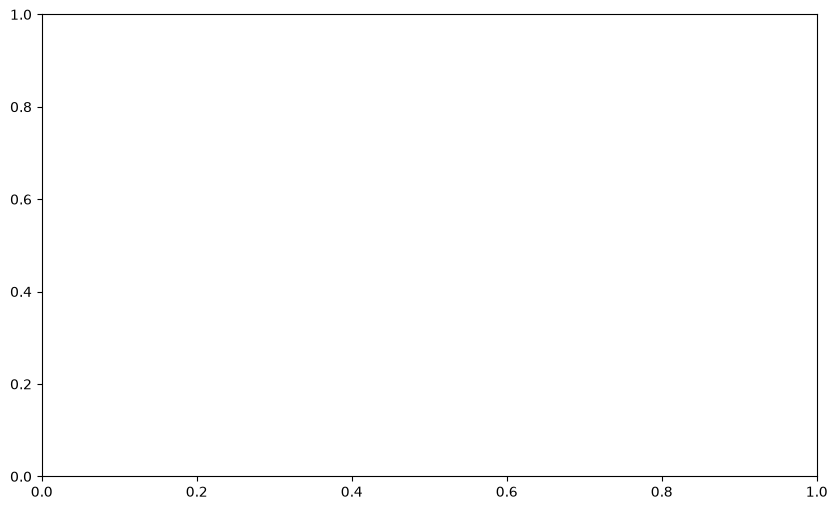

In [2]:
import matplotlib.pyplot as plt 

superhero_embeddings = {
    "Iron Man": [0.9, 0.8],
    "Batman": [0.85, 0.75],
    "Spider-Man": [0.7, 0.9],
    "Doctor Strange": [-0.8, 0.85],
    "Loki": [-0.9, -0.4],
    "Thanos": [0.2, -0.95]
}

fig, ax = plt.subplots(figsize=(10,6))

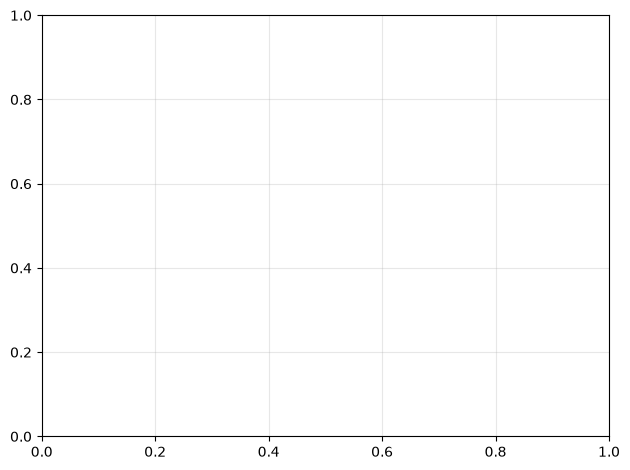

In [7]:
for hero, coords in superhero_embeddings.items():

    ax.scatter(coords[0], coords[1], s=200)

    ax.annotate(
        hero,
        (coords[0], coords[1]),
        xytext=(5,5),
        textcoords="offset points"
    )

ax.axhline(y=0,color='black',linewidth=0.5)
ax.axvline(x=0,color='black',linewidth=0.5)

ax.set_xlabel("Technology <-------> Magic")
ax.set_ylabel("Villain <-------> Hero")

ax.set_title("Superhero Embedding Space")

plt.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
query = [0.92, 0.82]

In [5]:
query

[0.92, 0.82]

In [6]:
import numpy as np

def cosine_similarity(v1, v2):

    dot_product = np.dot(v1, v2)

    norm1 = np.linalg.norm(v1)

    norm2 = np.linalg.norm(v2)

    return dot_product / (norm1 * norm2)

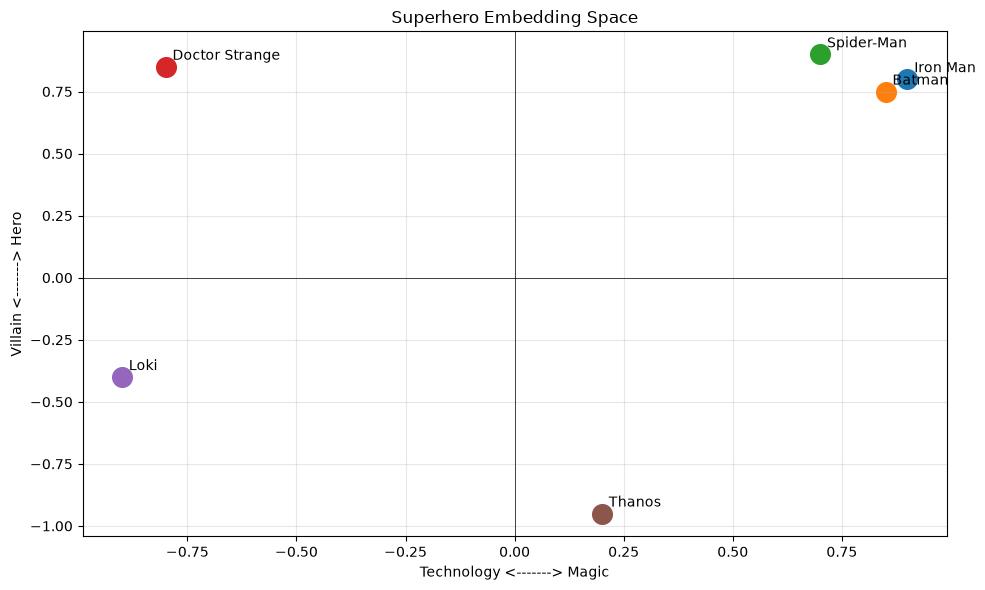

In [8]:
import matplotlib.pyplot as plt

superhero_embeddings = {
    "Iron Man": [0.9, 0.8],
    "Batman": [0.85, 0.75],
    "Spider-Man": [0.7, 0.9],
    "Doctor Strange": [-0.8, 0.85],
    "Loki": [-0.9, -0.4],
    "Thanos": [0.2, -0.95]
}

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

for hero, coords in superhero_embeddings.items():

    ax.scatter(coords[0], coords[1], s=200)

    ax.annotate(
        hero,
        (coords[0], coords[1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# X-axis line
ax.axhline(y=0, color='black', linewidth=0.5)

# Y-axis line
ax.axvline(x=0, color='black', linewidth=0.5)

ax.set_xlabel("Technology <-------> Magic")
ax.set_ylabel("Villain <-------> Hero")

ax.set_title("Superhero Embedding Space")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# How to measure similarity 

import numpy as np

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product / (norm_a * norm_b)

# [Technology, Heroism, Intelligence]

ironman_vector = [0.9, 0.8, 0.9]
batman_vector = [0.85, 0.75, 0.95]
thanos_vector = [0.2, -0.9, 0.8]

ironman_batman = cosine_similarity(
    ironman_vector,
    batman_vector
)

ironman_thanos = cosine_similarity(
    ironman_vector,
    thanos_vector
)

print("Iron Man vs Batman :", round(ironman_batman, 4))
print("Iron Man vs Thanos :", round(ironman_thanos, 4))

Iron Man vs Batman : 0.9984
Iron Man vs Thanos : 0.0981


In [10]:
#creating the first embedings

from langchain_huggingface import HuggingFaceEmbeddings
from ollama import embeddings


embeddings=HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

/Users/manojkrishnappa/github/Quantam-vector-Rag-Masterclass/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 27220.30it/s]


In [11]:
text = "Hello Everyone Goodevng this is Rag Master CLass"

embeding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embeding length: {len(embeding)}")
print(embeding)

Text: Hello Everyone Goodevng this is Rag Master CLass
Embeding length: 384
[-0.08130241930484772, 0.09409017860889435, 0.04183235764503479, -0.035182077437639236, -0.08540934324264526, -0.002984875813126564, 0.05113615468144417, -0.03516217693686485, -0.071739062666893, -0.008156536146998405, -0.02648889645934105, 0.008596147410571575, 0.05553243309259415, -0.09665054082870483, -0.03360089287161827, 0.047344598919153214, 0.060318753123283386, 0.07640998810529709, -0.024431614205241203, 0.039277333766222, -0.009115460328757763, 0.027245741337537766, -0.0425560437142849, -0.03251823037862778, -0.06725790351629257, 0.01466276589781046, 0.018962837755680084, -0.002921164268627763, 0.08432013541460037, -0.06035131216049194, -0.04220283776521683, 0.054139457643032074, -0.028815174475312233, 0.050356194376945496, -0.06410408765077591, 0.03628147765994072, -0.007805862929672003, 0.043543051928281784, -0.022545212879776955, 0.03233249858021736, 0.021983051672577858, 0.03612381964921951, -0.032

In [12]:
sentence = [
    "the cat sat on the mat",
    "the cat sat on the mat",
    "the dog played in the yard",
    "i love programing in python",
    "python is my fvt programing language"
]
embeding_sentence = embeddings.embed_documents(sentence)


In [17]:
len(embeding_sentence[0])


384

In [14]:
print(embeding_sentence[0])

[0.1304018348455429, -0.011870198883116245, -0.02811698243021965, 0.05123862251639366, -0.055974479764699936, 0.030191566795110703, 0.030161341652274132, 0.02469833754003048, -0.01837052032351494, 0.05876683071255684, -0.024953164160251617, 0.060154207050800323, 0.03983161970973015, 0.03323054313659668, -0.061311379075050354, -0.04937309771776199, -0.05486350134015083, -0.04007606953382492, 0.056429147720336914, 0.039156582206487656, -0.03473707288503647, -0.013247726485133171, 0.0319662019610405, -0.06349916756153107, -0.06017855927348137, 0.07823450863361359, -0.028303882107138634, -0.04744279757142067, 0.04035935178399086, -0.0066309040412306786, -0.06674094498157501, -0.004191333428025246, -0.025311680510640144, 0.053341638296842575, 0.017428040504455566, -0.0979236289858818, 0.006061288062483072, -0.06524162739515305, 0.04557256028056145, 0.023641863837838173, 0.07658480852842331, -0.010264343582093716, -0.004076786804944277, -0.06232284754514694, 0.033705174922943115, 0.018661102

In [15]:
print(embeding_sentence[1])

[0.1304018348455429, -0.011870198883116245, -0.02811698243021965, 0.05123862251639366, -0.055974479764699936, 0.030191566795110703, 0.030161341652274132, 0.02469833754003048, -0.01837052032351494, 0.05876683071255684, -0.024953164160251617, 0.060154207050800323, 0.03983161970973015, 0.03323054313659668, -0.061311379075050354, -0.04937309771776199, -0.05486350134015083, -0.04007606953382492, 0.056429147720336914, 0.039156582206487656, -0.03473707288503647, -0.013247726485133171, 0.0319662019610405, -0.06349916756153107, -0.06017855927348137, 0.07823450863361359, -0.028303882107138634, -0.04744279757142067, 0.04035935178399086, -0.0066309040412306786, -0.06674094498157501, -0.004191333428025246, -0.025311680510640144, 0.053341638296842575, 0.017428040504455566, -0.0979236289858818, 0.006061288062483072, -0.06524162739515305, 0.04557256028056145, 0.023641863837838173, 0.07658480852842331, -0.010264343582093716, -0.004076786804944277, -0.06232284754514694, 0.033705174922943115, 0.018661102

# popular models:
- all-MiniLM-L6-v2 == HuggingFace (fast and efficient and good quality)
- all-mpnet-base-v2

In [18]:


#creating the first embedings

from langchain_huggingface import HuggingFaceEmbeddings
from ollama import embeddings


embeddings=HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-mpnet-base-v2"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10233.52it/s]


In [19]:
text = "Hello Everyone Goodevng this is Rag Master CLass"

embeding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embeding length: {len(embeding)}")
print(embeding)

Text: Hello Everyone Goodevng this is Rag Master CLass
Embeding length: 768
[0.00869944877922535, 0.0162204522639513, 0.012199388816952705, 0.007738536223769188, 0.05476541072130203, 0.02090386301279068, -0.012022520415484905, 0.01901869848370552, -0.033486317843198776, -0.004398430231958628, -0.009446927346289158, -0.005267932079732418, 0.008289915509521961, -0.0030230525881052017, 0.057068098336458206, -0.017202338203787804, 0.04390759393572807, 0.026442380622029305, -0.10643177479505539, -0.007321520242840052, 0.021518634632229805, 0.00806453637778759, -0.006634362507611513, -0.009333154186606407, -0.02870955690741539, 0.028125476092100143, -5.910514300921932e-05, 0.014873606152832508, -0.039402514696121216, -0.06035442650318146, 0.013444746844470501, 0.01105118915438652, 0.019003650173544884, 0.04512462764978409, 2.245794348709751e-06, -0.029156958684325218, 0.015505945309996605, -0.018054161220788956, -0.06835464388132095, 0.06767711043357849, 0.06061588227748871, 0.04027467966079

In [25]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [26]:
from langchain_openai import OpenAIEmbeddings

embedings = OpenAIEmbeddings(
    model = "text-embedding-3-small"
)

In [27]:
embedings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x12bd54170>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x13325e030>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [28]:
single_text = "I am from qv and we are working on RAG masterclass"
single_emdedings=embedings.embed_query(single_text)
single_emdedings

[-0.028076171875,
 0.045989990234375,
 0.0267486572265625,
 -0.00753021240234375,
 -0.01204681396484375,
 0.006443023681640625,
 -0.028839111328125,
 -0.0096282958984375,
 -0.01233673095703125,
 -0.04046630859375,
 0.013214111328125,
 -0.00911712646484375,
 -0.037384033203125,
 0.034332275390625,
 0.0158233642578125,
 -0.014892578125,
 -0.0007071495056152344,
 -0.0023479461669921875,
 -0.00428009033203125,
 0.03521728515625,
 0.028472900390625,
 -0.01485443115234375,
 0.0389404296875,
 -0.0233001708984375,
 -0.0175628662109375,
 0.0021686553955078125,
 0.032958984375,
 0.054931640625,
 -0.0204620361328125,
 -0.0162506103515625,
 0.040252685546875,
 -0.041290283203125,
 -0.033203125,
 -0.005950927734375,
 0.0253448486328125,
 0.0159149169921875,
 0.029541015625,
 0.0184783935546875,
 -0.07525634765625,
 -0.005641937255859375,
 -0.049652099609375,
 -0.0256195068359375,
 0.0026092529296875,
 0.0172882080078125,
 0.0296478271484375,
 -0.002872467041015625,
 -0.0186767578125,
 0.01255798339

In [29]:
sentence = [
    "the cat sat on the mat",
    "the cat sat on the mat",
    "the dog played in the yard",
    "i love programing in python",
    "python is my fvt programing language"
]
embeding_sentence = embeddings.embed_documents(sentence)


In [30]:
embeding_sentence

[[-0.004790366627275944,
  -0.04454639181494713,
  -0.012947137467563152,
  -0.015809960663318634,
  0.016214970499277115,
  -0.04238872975111008,
  -0.017240455374121666,
  -0.009168928489089012,
  0.06041456013917923,
  0.008282006718218327,
  0.05595811456441879,
  0.030417444184422493,
  -0.016756571829319,
  -0.0072168828919529915,
  0.0472651831805706,
  0.08785630017518997,
  0.0011019001249223948,
  0.04230494424700737,
  0.02570982649922371,
  -0.00953584723174572,
  0.02513866126537323,
  0.004655067343264818,
  -0.00011658341099973768,
  0.027523444965481758,
  -0.07715398073196411,
  0.00826098769903183,
  -0.04457840695977211,
  -0.012338394299149513,
  -0.03978029638528824,
  -0.02995499223470688,
  0.03811980411410332,
  0.025839602574706078,
  0.010295652784407139,
  -0.1016622856259346,
  1.752128582666046e-06,
  -0.006307958625257015,
  -0.02511950209736824,
  -0.006967607419937849,
  0.10416091978549957,
  -0.06334695219993591,
  -0.032543327659368515,
  -0.036750398